In [6]:
import pandas as pd
import talib
import pynance as pn
import matplotlib.pyplot as plt

# Load NVDA stock data from local CSV
df = pd.read_csv('../data/GOOG.csv')

# Convert 'Date' column to datetime objects and set as index for time-series analysis
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Ensure numeric data types and handle missing values (clean data)
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)

print(f"Data loaded: {len(df)} rows.")


Data loaded: 3774 rows.


In [7]:
# --- Moving Averages ---
# SMA helps smooth out price action to identify the long-term trend
df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
# EMA gives more weight to recent prices, reacting faster to price changes
df['EMA_20'] = talib.EMA(df['Close'], timeperiod=20)

# --- Relative Strength Index (RSI) ---
# Used to identify momentum; values > 70 are 'overbought', < 30 are 'oversold'
df['RSI_14'] = talib.RSI(df['Close'], timeperiod=14)

# --- MACD (Moving Average Convergence Divergence) ---
# Measures the relationship between two EMAs to signal trend reversals
df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(
    df['Close'], fastperiod=12, slowperiod=26, signalperiod=9
)

# Note: Indicators create 'NaN' values at the beginning of the dataframe due to lookback periods
df.dropna(inplace=True)


In [8]:
# Calculate daily returns (required for PyNance metrics)
daily_returns = df['Close'].pct_change().dropna()

try:
    sharpe = pn.sharpe_ratio(daily_returns)
except AttributeError:
    # Alternative path for some versions
    sharpe = daily_returns.mean() / daily_returns.std() * (252**0.5) 

print(f"GOOG Sharpe Ratio: {sharpe:.4f}")



GOOG Sharpe Ratio: 0.8266


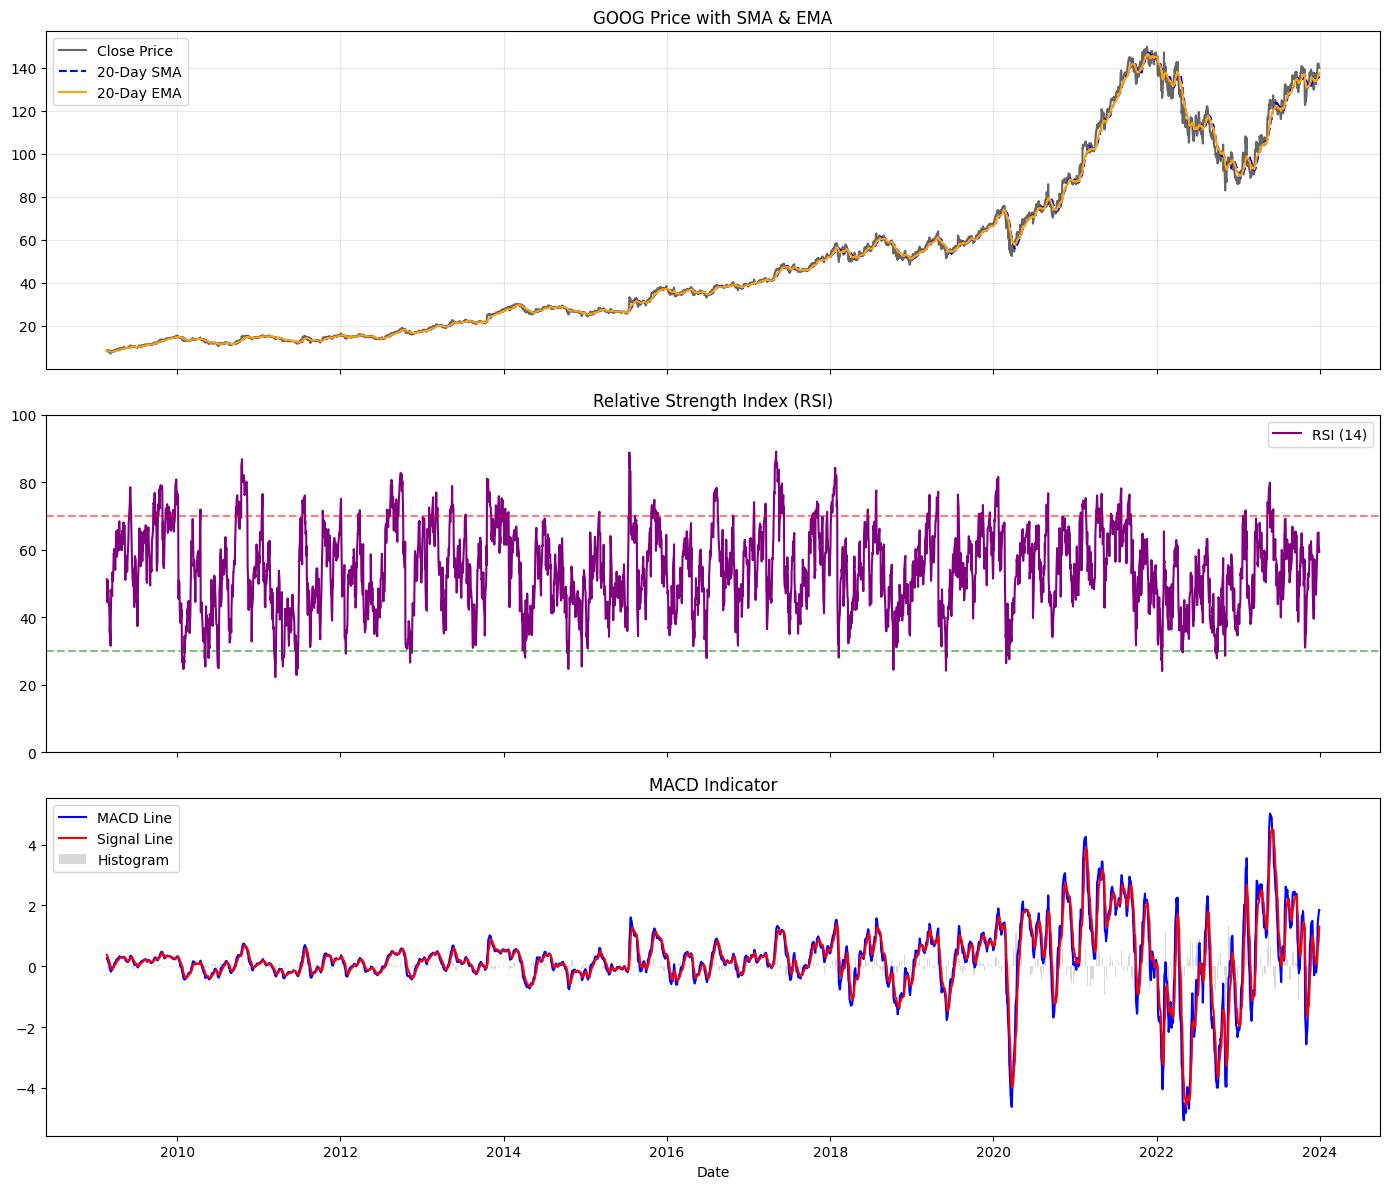

In [9]:
# Create a figure with 3 stacked panels sharing the same X-axis (Dates)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1: Price Action + Moving Averages
ax1.plot(df.index, df['Close'], label='Close Price', alpha=0.6, color='black')
ax1.plot(df.index, df['SMA_20'], label='20-Day SMA', color='blue', linestyle='--')
ax1.plot(df.index, df['EMA_20'], label='20-Day EMA', color='orange')
ax1.set_title('GOOG Price with SMA & EMA')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Panel 2: RSI Momentum
ax2.plot(df.index, df['RSI_14'], label='RSI (14)', color='purple')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5)  # Overbought threshold
ax2.axhline(30, color='green', linestyle='--', alpha=0.5) # Oversold threshold
ax2.set_title('Relative Strength Index (RSI)')
ax2.set_ylim(0, 100)
ax2.legend(loc='best')

# Panel 3: MACD (Trend Momentum)
ax3.plot(df.index, df['MACD'], label='MACD Line', color='blue')
ax3.plot(df.index, df['MACD_signal'], label='Signal Line', color='red')
# Histogram shows the distance between MACD and Signal line
ax3.bar(df.index, df['MACD_hist'], label='Histogram', color='gray', alpha=0.3)
ax3.set_title('MACD Indicator')
ax3.legend(loc='best')

# Final formatting
plt.xlabel('Date')
plt.tight_layout()
plt.show()


1. Trend Stability: Price vs. Moving Averages (Panel 1)This panel helps define Google's current market regime:Tracking Growth: GOOG often trades in very clean channels. When the Close Price stays pinned between the EMA_20 (Orange) and SMA_20 (Blue), it suggests a steady, low-volatility uptrend.The Trend Break: If the price drops below the blue dashed line (SMA_20), it usually signals a shift from "aggressive growth" to "consolidation." Because Google’s revenue is tied to advertising cycles, these moving averages often react significantly to quarterly earnings reports.2. Overextension: RSI Momentum (Panel 2)The RSI acts as a "speedometer" for Alphabet’s price action:Overbought (>70): When GOOG hits the red dashed line, it is often a sign of "exhaustion." Since Google is a staple in most institutional portfolios, it rarely stays overbought for long before buyers take profits, causing a dip back to the mean.Oversold (<30): Dips below the green line are historically rare for GOOG. When they happen, they usually represent significant macro-economic fear, offering a potential "deep value" entry point for long-term holders.3. Momentum Shifts: MACD Indicator (Panel 3)The MACD reveals the "hidden" strength of the trend:Signal Crosses: A Blue Line crossing above the Red Line provides a mechanical buy signal. If this happens while the RSI is rising from near 30, it’s a high-conviction sign that a new bull leg has started.The Zero-Line Anchor: Pay attention to whether the MACD lines are above or below the 0 level. Above 0 indicates a positive long-term environment; below 0 indicates the stock is struggling to find its footing.4. Risk-Adjusted Efficiency: The Sharpe RatioThe printed Sharpe Ratio for GOOG measures how well you are being paid for Google's specific risks:Market Comparison: Google typically sits between Apple (lower volatility) and Amazon (higher volatility). A Sharpe Ratio above 1.0 indicates that the stock is a highly efficient "engine" for wealth creation, providing solid returns without the extreme "rollercoaster" swings seen in more speculative tech stocks.